## Referencias

Se tomó como ayuda el siguiente notebook: https://www.kaggle.com/code/balraj98/yolo-v5-car-object-detection


## Setup

Instalacion de librerias

In [ ]:
!pip install tensorflow
!pip install opencv-python
!pip install kagglehub
!pip install numpy
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.4 MB/s eta 0:00:00


Imports Necesarios

In [ ]:
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import shutil
from google.colab.patches import cv2_imshow
import tensorflow as tf
import numpy as np
import kagglehub
import ultralytics
import os
from ultralytics import YOLO
import glob
import random
import tensorflow as tf
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Preprocesamiento del Dataset para poder entrenar a YoloV8

Cargar imagenes de entrenamiento desde kaggle

In [ ]:
path = kagglehub.dataset_download("sshikamaru/car-object-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-object-detection' dataset.
Path to dataset files: /kaggle/input/car-object-detection


El dataset original se encuentra en formato [nombre_imagen,Xmin,Ymin,Xmax,Ymax]; es necesario calcular la coordenada central de la bounding box, así como el alto y ancho de cada caja donde se encierra el objeto detectado

In [ ]:
img_h, img_w, num_channels = (380, 676, 3)
df = pd.read_csv('../kaggle/input/car-object-detection/data/train_solution_bounding_boxes (1).csv')
df.rename(columns={'image':'image_id'}, inplace=True)
df['image_id'] = df['image_id'].apply(lambda x: x.split('.')[0])
df['x_center'] = (df['xmin'] + df['xmax'])/2
df['y_center'] = (df['ymin'] + df['ymax'])/2
df['w'] = df['xmax'] - df['xmin']
df['h'] = df['ymax'] - df['ymin']
df['classes'] = 0 # La clase 0 indica que la detección es un Carro
df['x_center'] = df['x_center']/img_w
df['w'] = df['w']/img_w
df['y_center'] = df['y_center']/img_h
df['h'] = df['h']/img_h
df.head()

,image_id,xmin,ymin,xmax,ymax,x_center,y_center,w,h,classes
0,vid_4_1000,281.259045,187.035071,327.727931,223.225547,0.450434,0.539817,0.068741,0.095238,0
1,vid_4_10000,15.163531,187.035071,120.329957,236.430180,0.100217,0.557191,0.155572,0.129987,0
2,vid_4_10040,239.192475,176.764801,361.968162,236.430180,0.444645,0.543678,0.181621,0.157014,0
3,vid_4_10020,496.483358,172.363256,630.020260,231.539575,0.833213,0.531451,0.197540,0.155727,0
4,vid_4_10060,16.630970,186.546010,132.558611,238.386422,0.110347,0.559122,0.171491,0.136422,0


Comandos para crear el acceso simbolico a las imagenes (de la carpeta kaggle), puesto que esta carpeta no se puede modificar como tal, se debe crear un acceso desde el content

In [ ]:
# Creamos una carpeta en content para que sirva de puente
!mkdir -p /content/datasets/train

# Creamos un acceso directo a las imágenes de Kaggle dentro de nuestra carpeta
!ln -s /kaggle/input/car-object-detection/data/training_images /content/datasets/images


# Creamos la carpeta de labels
!mkdir -p /content/datasets/train/labels

Crear los labels para cada imagen según el archivo csv que relaciona ambas

In [ ]:
csv_path = '/kaggle/input/car-object-detection/data/train_solution_bounding_boxes (1).csv' # Archivo csv que relaciona imagenes con su bounding_box
images_dir = '/content/datasets/images' # Carpeta de imagenes (el acceso directo a la carpeta de kaggle)
labels_dir = '/content/datasets/train/labels' # Carpeta de labels
os.makedirs(labels_dir, exist_ok=True)

for filename, group in df.groupby('image_id'):
    img_path = os.path.join(images_dir, filename + '.jpg') # Obtener el path de cada imagen en el archivo CSV
    if not os.path.exists(img_path):
        continue
    label_path = os.path.join(labels_dir, filename + '.txt') # Obtener el path del label relacionado a la imagen
    with open(label_path, 'w') as f: # Crear el archivo .txt correspondiente al label de cada imagen
        for _, row in group.iterrows():
            # Formato YOLO: class_id x_center y_center width height
            f.write(f"{row['classes']} {row['x_center']} {row['y_center']} {row['w']} {row['h']}\n")

Seleccionar las imagenes que contienen label y guardarlas en la carpeta de train/images, las demás se usan como background

In [ ]:
# Crear carpeta para el set filtrado
os.makedirs('/content/datasets/train/images', exist_ok=True)

labels_list = [f.replace('.txt', '.jpg') for f in os.listdir('/content/datasets/train/labels')]

for img_name in labels_list:
    src = os.path.join('/content/datasets/images', img_name)
    dst = os.path.join('/content/datasets/train/images', img_name)
    if os.path.exists(src):
        shutil.copy(src, dst)

print(f"Copiadas {len(os.listdir('/content/datasets/train/images'))} imágenes coincidentes.")

Copiadas 355 imágenes coincidentes.


Escribir el data.yaml para el entrenamiento de YoloV8

Nota: Modificar los paths en caso de cambiar la ubicacion de los elementos

In [ ]:
%%writefile dataset.yaml
path: /content/datasets
train: train/images
val: train/images # Se usa la misma carpeta de train de forma temporal
names:
  0: carro

Writing dataset.yaml


## Entrenamiento de yoloV8 para identificar Vehículos (obtener los pesos del modelo y precargarlo)

In [ ]:

!mkdir -p /content/datasets/labels

In [ ]:
# Creamos un enlace simbólico: /content/datasets/images -> Carpeta de Kaggle
#!ln -s /kaggle/input/car-object-detection/data/training_images /content/datasets/images

ln: failed to create symbolic link '/content/datasets/images/training_images': Read-only file system


Verificar si el número de imágenes corresponde al número de labels para realizar el entrenamiento

In [ ]:
img_count = len(os.listdir('/content/datasets/train/images'))
lbl_count = len(os.listdir('/content/datasets/train/labels'))

print(f"Imágenes encontradas: {img_count}")
print(f"Etiquetas (.txt) encontradas: {lbl_count}")

if lbl_count == 0:
    print(" ERROR: Todavía no hay etiquetas en /content/datasets/train/labels")
elif lbl_count < img_count:
    print(" ADVERTENCIA: Menos etiquetas que imágenes.")
else:
    print(" TODO LISTO: Se puede empezar a entrenar.")

Imágenes encontradas: 355
Etiquetas (.txt) encontradas: 355
✅ TODO LISTO: Puedes empezar a entrenar.


Descargar YoloV8

In [ ]:
model = YOLO('yolov8s.pt')

Borrar cache de yolo

In [ ]:
!rm -f /content/datasets/*.cache
!rm -f /content/datasets/train_images_filtered/*.cache

Entrenar Yolo

In [ ]:
results = model.train(
    data='dataset.yaml',   # El archivo .yaml
    epochs=5,             # Epocas de aprendizaje
    imgsz=640,             # Tamaño de las imágenes
    batch=16,              # Cantidad de imágenes que procesa a la vez
    name='yolo_carros',    # Nombre de la carpeta de resultados
    device=0               # Usar GPU para entrenar
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_carros, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=Tru

## Predicciones

Cargar los pesos del mejor modelo obtenido durante el entrenamiento

In [ ]:
parking_model = YOLO('runs/detect/yolo_carros/weights/best.pt')

Realizar la predicción

In [ ]:
results = model.predict(source='parking_test_photo.jpg', conf=0.25, save=True)


image 1/1 /content/parking_test_photo.jpg: 288x640 1 carro, 50.0ms
Speed: 1.5ms preprocess, 50.0ms inference, 1.4ms postprocess per image at shape (1, 3, 288, 640)
Results saved to /content/runs/detect/predict


Graficar la detección

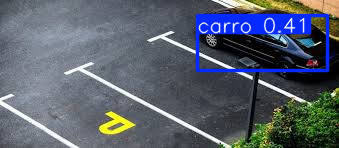

In [ ]:
for r in results:
    im_array = r.plot()
    cv2_imshow(im_array)